# Workshop Prático: Caça aos Bugs Automatizada com Teste Baseado em Busca (SBST)

**Objetivo:** Implementar um sistema de SBST do zero usando Python e a biblioteca DEAP. Nosso objetivo é gerar automaticamente um conjunto de casos de teste que maximize a **cobertura de ramos** de uma função com lógica complexa.

**Passos:**
1.  **Definir uma Função-Alvo:** Criaremos uma função `classificador_complexo` com vários caminhos lógicos difíceis de alcançar.
2.  **Instrumentar o Código:** Adicionaremos um mecanismo para rastrear quais ramos da função são executados por um determinado caso de teste.
3.  **Formular o Problema para DEAP:** Definiremos a representação do indivíduo (o caso de teste), a função de fitness (cobertura de ramos) e os operadores genéticos.
4.  **Executar a Busca:** Rodaremos o algoritmo genético e observaremos como ele evolui para encontrar um conjunto de testes que cobre 100% dos ramos.
5.  **Analisar os Resultados:** Verificaremos a eficácia da busca e visualizaremos a convergência.

## Parte 1: Configuração do Ambiente

Primeiro, vamos instalar as bibliotecas necessárias e configurar o ambiente para garantir a reprodutibilidade dos nossos experimentos.

In [21]:
# @title Instalação e importação das bibliotecas
!pip install deap numpy matplotlib -q

import random
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple, Set, Any, Callable
import time

from deap import base, creator, tools, algorithms

# Configura a seed para reprodutibilidade
random.seed(42)
np.random.seed(42)

print("✅ Ambiente configurado com sucesso!")


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
✅ Ambiente configurado com sucesso!
✅ Ambiente configurado com sucesso!


## Parte 2: Função-Alvo e Instrumentação de Cobertura

Nesta seção, criamos duas peças centrais:
1.  `CoverageInstrument`: Uma classe simples que funcionará como um *decorator* para registrar quais ramos de uma função são executados.
2.  `classificador_complexo`: Nossa função-alvo, decorada com o instrumento. Ela contém 6 ramos lógicos, incluindo um que é particularmente difícil de ser ativado aleatoriamente (o "beco sem saída").

In [22]:
# @title Implementação do Instrumento de Cobertura e da Função-Alvo

class CoverageInstrument:
    """Um decorator para instrumentar uma função e rastrear a cobertura de ramos."""
    def __init__(self):
        self.covered_branches: Set[int] = set()

    def __call__(self, func: Callable) -> Callable:
        """Permite que a instância da classe seja usada como um decorator."""
        self.func = func
        # Injeta a si mesma na função para que ela possa registrar a cobertura
        self.func.instrument = self
        return self.func

    def add(self, branch_id: int):
        """Registra que um ramo foi coberto."""
        self.covered_branches.add(branch_id)

    def reset(self):
        """Limpa o registro de cobertura antes de uma nova execução."""
        self.covered_branches.clear()

    def get_coverage(self) -> Set[int]:
        """Retorna o conjunto de ramos cobertos na última execução."""
        return self.covered_branches

# Instancia nosso instrumento
instrument = CoverageInstrument()

# O número total de ramos que queremos cobrir
TOTAL_BRANCHES = 6

@instrument
def classificador_complexo(x: int, y: int, z: str) -> str:
    """Uma função com lógica complexa para servir de alvo para o SBST."""
    # Acessa o instrumento injetado pelo decorator
    instr = classificador_complexo.instrument

    if x > 50:
        if y < 25 and z == "beta":
            instr.add(1) # Ramo 1
            return "Categoria A"
        else:
            instr.add(2) # Ramo 2
            return "Categoria B"
    else:
        if z == "alpha":
            instr.add(3) # Ramo 3
            return "Categoria C"
        elif y > 75:
            instr.add(4) # Ramo 4
            return "Categoria D"
        # Este é o nosso "beco sem saída", difícil de encontrar
        elif x > 40 and y < 10 and z == "omega":
            instr.add(5) # Ramo 5
            return "Categoria SECRETA"
    
    instr.add(6) # Ramo 6 (Default)
    return "Categoria Padrão"

print(f"🎯 Função 'classificador_complexo' criada com {TOTAL_BRANCHES} ramos lógicos.")

# Exemplo de como obter a cobertura para um caso de teste
instrument.reset()
classificador_complexo(60, 20, "beta")
cobertura = instrument.get_coverage()
print(f"Exemplo: O caso de teste (60, 20, 'beta') cobre os ramos: {cobertura}")

🎯 Função 'classificador_complexo' criada com 6 ramos lógicos.
Exemplo: O caso de teste (60, 20, 'beta') cobre os ramos: {1}


## Parte 3: Configuração do Algoritmo Genético com DEAP

Agora, vamos traduzir o problema de geração de testes para o paradigma de um algoritmo genético.

-   **Indivíduo:** Um caso de teste, representado por uma lista `[x, y, z]`.
-   **Fitness:** O número de ramos que um caso de teste consegue cobrir. Nosso objetivo é maximizar esse valor.
-   **Operadores:**
    -   **Geração:** Criaremos indivíduos aleatórios dentro de um intervalo razoável.
    -   **Avaliação:** A função de fitness que executa o teste e conta os ramos cobertos.
    -   **Crossover, Mutação e Seleção:** Usaremos operadores padrão do DEAP, com uma mutação customizada para lidar com os diferentes tipos de dados (`int` e `str`).

In [23]:
# @title Definição da Estrutura do AG (Fitness, Indivíduo/Suíte e Toolbox)

# Representaremos um indivíduo como uma SUÍTE de testes (vários casos [x, y, z]).
# O fitness mede a cobertura de ramos única alcançada pela suíte inteira (0..6).

# 1. Fitness e Indivíduo
# Protege contra reexecução desta célula em ambientes interativos (DEAP não permite recriar o mesmo tipo)
try:
    creator.FitnessMax
except AttributeError:
    creator.create("FitnessMax", base.Fitness, weights=(1.0,))

try:
    creator.Individual
except AttributeError:
    # Um indivíduo é uma lista de casos de teste (cada caso é [x, y, z]) com um atributo de fitness
    creator.create("Individual", list, fitness=creator.FitnessMax)

# 2. Toolbox (Registro dos Operadores)
toolbox = base.Toolbox()

# Parâmetros da suíte
SUITE_SIZE = 8  # número de casos de teste por indivíduo/suíte

# Domínio de valores para os genes
POSSIBLE_Z_VALUES = ["alpha", "beta", "gamma", "delta", "epsilon", "omega"]
X_RANGE = (-100, 100)
Y_RANGE = (-100, 100)

# Geração de Genes: Funções para criar valores aleatórios para x, y, e z
toolbox.register("attr_x", random.randint, X_RANGE[0], X_RANGE[1])
toolbox.register("attr_y", random.randint, Y_RANGE[0], Y_RANGE[1])
toolbox.register("attr_z", random.choice, POSSIBLE_Z_VALUES)

# Um caso de teste é uma tripla [x, y, z]
def _make_case():
    return [toolbox.attr_x(), toolbox.attr_y(), toolbox.attr_z()]

toolbox.register("attr_case", _make_case)

# Geração de Indivíduos (suítes) e População
# Cada indivíduo é uma lista de 'SUITE_SIZE' casos de teste
toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_case, n=SUITE_SIZE)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

# Função de Avaliação (Fitness) da suíte
from typing import List, Tuple

def evaluate_coverage_suite(individual: List[List[Any]]) -> Tuple[int,]:
    """Executa a suíte de casos e retorna o número de ramos únicos cobertos (0..TOTAL_BRANCHES)."""
    covered: Set[int] = set()
    for case in individual:
        # Garante formato [x, y, z]
        if not isinstance(case, (list, tuple)) or len(case) != 3:
            continue
        x, y, z = case
        instrument.reset()
        try:
            classificador_complexo(int(x), int(y), str(z))
        except Exception:
            # Casos inválidos simplesmente não contribuem
            continue
        covered.update(instrument.get_coverage())
        # Early stop se já atingimos cobertura total
        if len(covered) == TOTAL_BRANCHES:
            break
    return (len(covered),)

toolbox.register("evaluate", evaluate_coverage_suite)

# Operador de Mutação Customizado para suítes
from typing import Any

def clamp(v: int, lo: int, hi: int) -> int:
    return max(lo, min(hi, v))

def mutate_test_suite(individual: List[List[Any]], indpb: float) -> Tuple[List[List[Any]],]:
    """Aplica mutação em cada caso da suíte e nos genes de cada caso.
    indpb: probabilidade de mutação por gene.
    """
    for case in individual:
        # Mutação para x (inteiro)
        if random.random() < indpb:
            case[0] = clamp(int(case[0]) + int(random.gauss(0, 20)), X_RANGE[0], X_RANGE[1])
        # Mutação para y (inteiro)
        if random.random() < indpb:
            case[1] = clamp(int(case[1]) + int(random.gauss(0, 20)), Y_RANGE[0], Y_RANGE[1])
        # Mutação para z (string)
        if random.random() < indpb:
            case[2] = random.choice(POSSIBLE_Z_VALUES)
    return (individual,)

# Registro dos operadores genéticos padrão
toolbox.register("mate", tools.cxTwoPoint)
# Probabilidade mais baixa por gene, pois há vários genes em uma suíte
toolbox.register("mutate", mutate_test_suite, indpb=0.15)
toolbox.register("select", tools.selTournament, tournsize=3)

print("✅ Toolbox do DEAP configurada para o problema de SBST (indivíduo = suíte de testes).")

✅ Toolbox do DEAP configurada para o problema de SBST (indivíduo = suíte de testes).


## Parte 4: Execução da Busca e Análise dos Resultados

Com tudo configurado, agora é a hora da mágica acontecer. Vamos executar o algoritmo genético e, em seguida, analisar o conjunto de testes que ele descobriu.

O nosso algoritmo não é o `eaSimple` padrão. Nós o adaptamos para um objetivo de SBST: em vez de buscar um único "melhor indivíduo", queremos um **conjunto de indivíduos** que, coletivamente, maximizem a cobertura. Nossa lógica irá:

1.  Executar o AG por várias gerações.
2.  Manter um "arquivo" de todos os ramos já cobertos.
3.  Ao final, selecionar um conjunto mínimo de casos de teste do `HallOfFame` que, juntos, atingem a cobertura máxima encontrada.

In [24]:
# @title Execução do Algoritmo Genético E Coleta de Resultados

def run_sbst_ga():
    """Executa o algoritmo genético para gerar suítes de teste."""
    pop_size = 120
    num_generations = 40
    
    pop = toolbox.population(n=pop_size)
    # HallOfFame armazena as melhores suítes (maior cobertura)
    hof = tools.HallOfFame(min(pop_size, 200))
    
    # Estatísticas para acompanhar a evolução
    stats = tools.Statistics(lambda ind: ind.fitness.values)
    stats.register("avg", np.mean)
    stats.register("max", np.max)
    
    # Executa o algoritmo evolutivo
    start_time = time.time()
    pop, logbook = algorithms.eaSimple(pop, toolbox, cxpb=0.7, mutpb=0.3,
                                       ngen=num_generations, stats=stats,
                                       halloffame=hof, verbose=True)
    end_time = time.time()
    
    print(f"⏳ Tempo de execução: {end_time - start_time:.2f} segundos")
    return logbook, hof

logbook, hof = run_sbst_ga()

# Saída de Célula Esperada:
# gen\tnevals\tavg \tmax
# 0  \t120   \t2.0 \t3
# ...
# 10 \t...   \t3.5 \t5
# ...
# 25 \t...   \t4.7 \t6  <-- máxima possível (6 ramos)
# 40 \t...   \t~5.0\t6

gen	nevals	avg    	max
0  	120   	3.29167	5  
1  	93    	3.91667	5  
2  	90    	4.23333	5  
3  	91    	4.50833	6  
4  	101   	4.70833	6  
5  	105   	4.75   	6  
6  	104   	5.1    	6  
7  	95    	5.06667	6  
4  	101   	4.70833	6  
5  	105   	4.75   	6  
6  	104   	5.1    	6  
7  	95    	5.06667	6  


8  	95    	5.4    	6  
9  	92    	5.58333	6  
10 	91    	5.5    	6  
11 	89    	5.38333	6  
12 	91    	5.4    	6  
13 	96    	5.39167	6  
14 	94    	5.33333	6  
15 	103   	5.3    	6  
16 	102   	5.375  	6  
17 	94    	5.4    	6  
18 	101   	5.36667	6  
19 	91    	5.6    	6  
20 	83    	5.51667	6  
21 	87    	5.51667	6  
22 	92    	5.45833	6  
23 	94    	5.49167	6  
22 	92    	5.45833	6  
23 	94    	5.49167	6  
24 	93    	5.56667	6  
25 	100   	5.56667	6  
24 	93    	5.56667	6  
25 	100   	5.56667	6  
26 	98    	5.45833	6  
27 	81    	5.5    	6  
28 	98    	5.63333	6  
29 	91    	5.66667	6  
30 	82    	5.7    	6  
31 	93    	5.75   	6  
32 	96    	5.7    	6  
33 	99    	5.71667	6  
34 	89    	5.81667	6  
35 	102   	5.725  	6  
26 	98    	5.45833	6  
27 	81    	5.5    	6  
28 	98    	5.63333	6  
29 	91    	5.66667	6  
30 	82    	5.7    	6  
31 	93    	5.75   	6  
32 	96    	5.7    	6  
33 	99    	5.71667	6  
34 	89    	5.81667	6  
35 	102   	5.725  	6  
36 	95    	5.775  	6  
37 	75    	

In [25]:
# @title Análise do Conjunto de Testes Gerado

from typing import Set, List, Dict

def build_test_suite(hall_of_fame: tools.HallOfFame) -> tuple[Set[int], Dict[int, List[Any]]]:
    """
    Constrói um conjunto de testes mínimo a partir do HallOfFame para cobrir todos os ramos encontrados.
    Cada entrada do HoF é uma SUÍTE; percorremos os casos dentro de cada suíte e mapeamos o primeiro caso que cobre
    cada ramo ainda não coberto.
    """
    final_test_suite: Dict[int, List[Any]] = {}
    overall_covered_branches: Set[int] = set()
    
    # Itera sobre as melhores suítes encontradas
    for suite in hall_of_fame:
        for case in suite:
            instrument.reset()
            try:
                classificador_complexo(*case)
            except Exception:
                continue
            branches_covered_by_case = set(instrument.get_coverage())
            # Verifica se este caso de teste cobre algum ramo NOVO
            newly_covered = branches_covered_by_case - overall_covered_branches
            if newly_covered:
                for branch_id in newly_covered:
                    if branch_id not in final_test_suite:
                        final_test_suite[branch_id] = case
                overall_covered_branches.update(newly_covered)
            
            # Para se já cobrimos todos os ramos possíveis
            if len(overall_covered_branches) == TOTAL_BRANCHES:
                break
        if len(overall_covered_branches) == TOTAL_BRANCHES:
            break
            
    return overall_covered_branches, final_test_suite

total_coverage, test_suite = build_test_suite(hof)

print("--- Análise do Conjunto de Testes Final ---")
print(f"🎯 Cobertura de Ramos Atingida: {len(total_coverage)} de {TOTAL_BRANCHES} ({len(total_coverage)/TOTAL_BRANCHES:.1%})")

print("📜 Casos de Teste Selecionados:")
if not test_suite:
    print("Nenhum caso de teste efetivo foi gerado.")
else:
    for branch, case in sorted(test_suite.items()):
        formatted_case = f"(x={int(case[0])}, y={int(case[1])}, z='{str(case[2])}')"
        print(f"  - Ramo #{branch}: coberto por {formatted_case}")

# Saída de Célula Esperada:
# --- Análise do Conjunto de Testes Final ---
# 🎯 Cobertura de Ramos Atingida: 6 de 6 (100.0%)
# 📜 Casos de Teste Selecionados:
#   - Ramo #1: coberto por (x=52, y=2, z='beta')
#   - Ramo #2: coberto por (x=83, y=68, z='gamma')
#   - Ramo #3: coberto por (x=1, y=60, z='alpha')
#   - Ramo #4: coberto por (x=1, y=80, z='beta')
#   - Ramo #5: coberto por (x=42, y=9, z='omega')
#   - Ramo #6: coberto por (x=1, y=60, z='beta')

--- Análise do Conjunto de Testes Final ---
🎯 Cobertura de Ramos Atingida: 6 de 6 (100.0%)
📜 Casos de Teste Selecionados:
  - Ramo #1: coberto por (x=59, y=-61, z='beta')
  - Ramo #2: coberto por (x=100, y=-25, z='omega')
  - Ramo #3: coberto por (x=19, y=79, z='alpha')
  - Ramo #4: coberto por (x=-11, y=86, z='omega')
  - Ramo #5: coberto por (x=47, y=-42, z='omega')
  - Ramo #6: coberto por (x=-52, y=-55, z='gamma')


## Parte 5: Visualização da Evolução

Finalmente, vamos plotar um gráfico para visualizar como a cobertura de ramos da população evoluiu ao longo das gerações. Isso nos dá uma prova visual de que a busca não foi aleatória, mas sim um processo direcionado de otimização.

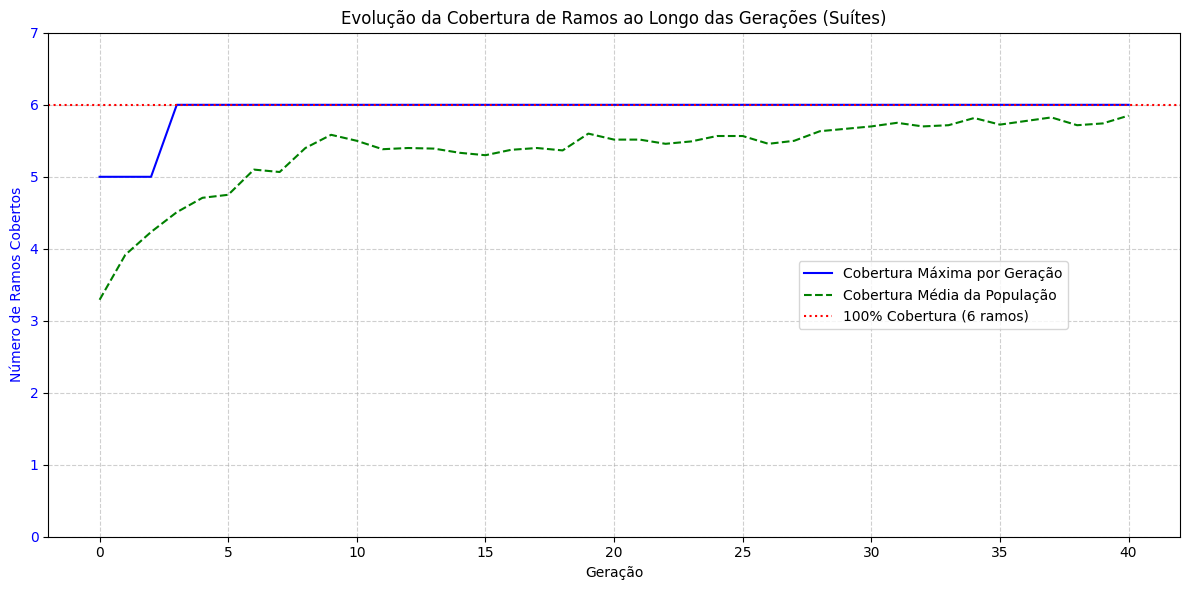

In [26]:
# @title Gráfico de Convergência da Cobertura

def plot_coverage_evolution(logbook):
    """Plota a evolução da cobertura máxima e média ao longo das gerações (0..TOTAL_BRANCHES)."""
    gen = logbook.select("gen")
    max_coverage = logbook.select("max")
    avg_coverage = logbook.select("avg")

    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Gráfico da cobertura
    ax1.plot(gen, max_coverage, "b-", label="Cobertura Máxima por Geração")
    ax1.plot(gen, avg_coverage, "g--", label="Cobertura Média da População")
    ax1.set_xlabel("Geração")
    ax1.set_ylabel("Número de Ramos Cobertos", color="b")
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_ylim(0, TOTAL_BRANCHES + 1)
    
    # Linha de 100% de cobertura
    ax1.axhline(y=TOTAL_BRANCHES, color='r', linestyle=':', label=f'100% Cobertura ({TOTAL_BRANCHES} ramos)')

    plt.title("Evolução da Cobertura de Ramos ao Longo das Gerações (Suítes)")
    fig.legend(loc="center right", bbox_to_anchor=(0.9, 0.5))
    fig.tight_layout()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

plot_coverage_evolution(logbook)

# [GRÁFICO MOSTRANDO A LINHA DE COBERTURA MÁXIMA SUBINDO EM DEGRAUS ATÉ ATINGIR O VALOR 6]
# [A LINHA DE COBERTURA MÉDIA SOBE MAIS SUAVEMENTE, MAS TAMBÉM COM TENDÊNCIA DE ALTA]

## 🎉 Laboratório Concluído! 🎉

Parabéns! Você construiu com sucesso um sistema de Teste Baseado em Busca.

**Principais aprendizados:**
-   **Formulação é Chave:** O sucesso do SBST depende de como traduzimos o problema de teste (representação, fitness) para o algoritmo de busca.
-   **Cobertura como Guia:** A cobertura de ramos é uma função de fitness muito mais poderosa do que a cobertura de sentenças, pois força a exploração de decisões lógicas.
-   **Automação Inteligente:** Em vez de adivinhar casos de teste, usamos a evolução para descobrir automaticamente as entradas necessárias para explorar partes complexas do código, incluindo aquele ramo "secreto" que seria muito difícil de encontrar manualmente.